In [12]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math

### Comparison between MC and MD simulations

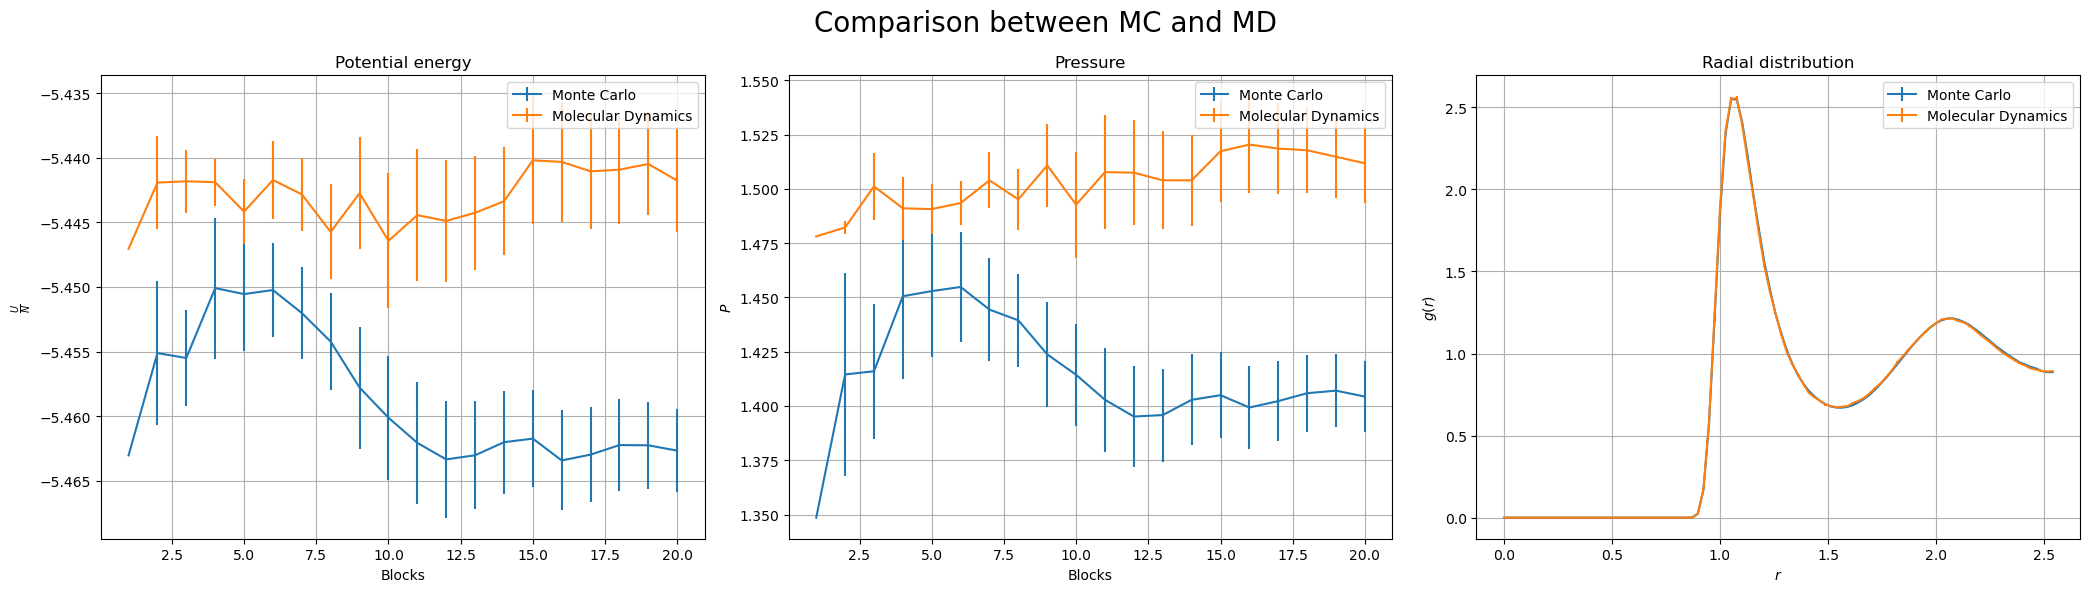

In [13]:
blocks, penergy_MC, pen_error_MC = np.loadtxt("../OUTPUT/MC/potential_energy.dat", usecols=(0,2,3),skiprows=1, unpack='true')
pressure_MC, pr_error_MC = np.loadtxt("../OUTPUT/MC/pressure.dat", usecols=(2,3),skiprows=1, unpack='true')
r, gofr_MC, gofr_error_MC = np.loadtxt("../OUTPUT/MC/gofr.dat", usecols=(0,1,2),skiprows=1, unpack='true')

penergy_MD, pen_error_MD = np.loadtxt("../OUTPUT/MD/potential_energy.dat", usecols=(2,3),skiprows=1, unpack='true')
pressure_MD, pr_error_MD = np.loadtxt("../OUTPUT/MD/pressure.dat", usecols=(2,3),skiprows=1, unpack='true')
gofr_MD, gofr_error_MD = np.loadtxt("../OUTPUT/MD/gofr.dat", usecols=(1,2),skiprows=1, unpack='true')

fig, axs = plt.subplots(1, 3, figsize=(21,6))

axs[0].errorbar(blocks,penergy_MC,yerr=pen_error_MC,label="Monte Carlo")
axs[0].errorbar(blocks,penergy_MD,yerr=pen_error_MD,label="Molecular Dynamics")
axs[0].set_xlabel("Blocks")
axs[0].set_ylabel("$\\frac{U}{N}$")
axs[0].set_title("Potential energy")
axs[0].legend()
axs[0].grid(True)

axs[1].errorbar(blocks,pressure_MC,yerr=pr_error_MC,label="Monte Carlo")
axs[1].errorbar(blocks,pressure_MD,yerr=pr_error_MD,label="Molecular Dynamics")
axs[1].set_xlabel("Blocks")
axs[1].set_ylabel("$P$")
axs[1].set_title("Pressure")
axs[1].legend()
axs[1].grid(True)

axs[2].errorbar(r,gofr_MC,yerr=gofr_error_MC,label="Monte Carlo")
axs[2].errorbar(r,gofr_MD,yerr=gofr_error_MD,label="Molecular Dynamics")
axs[2].set_xlabel("$r$")
axs[2].set_ylabel("$g(r)$")
axs[2].set_title("Radial distribution")
axs[2].legend()
axs[2].grid(True)

fig.suptitle("Comparison between MC and MD", fontsize=20)
plt.tight_layout()
plt.show()

### Commenti
Per entrambe le simulazioni è stata condotta prima un'equilibrazione di $2 \cdot 10^4$ steps. Nel caso della Dinamica Molecolare è stato utilizzato un time step $dt = 0.001$ ed è stata impostata una temperatura iniziale $T = 2.0$ in modo da ottenere, una volta equilibrato il sistema, una temperatura $T^* = 1.106 \pm 0.003$. Nel caso di Monte Carlo è stata impostata una temperatura $T = 1.1$ e un time step $dt = 0.1$. Successivamente, le simulazioni sono state eseguite con $20$ blocchi da $2000$ steps per un totale di $4 \cdot 10^4$ steps.

Come si può osservare dai grafici, gli andamenti delle propretà del sistema sono abbastanza simili (si noti in particolare la scala sull'asse delle ordinate) e le lievi discrepanze, che si riscontrano solo in pressione ed energia potenziale, possono essere ricondotte al fatto che le temperature delle due simulazioni non siano esattamente equivalenti. In particolare, mentre l'algoritmo di Monte Carlo lavora a temperatura fissata, quello di Dinamica Molecolare vede la temperatura oscillare attorno all'equilibrio raggiunto preliminarmente. Nonostante questo, i risultati delle due simulazioni sono in diversi punti compatibili entro le $2 \sigma$.